In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Carga y revisión general

La fuente corresponde a la tabla de población por grupos de edad del Censo 2024. La hoja utilizada fue exportada a CSV y cargada desde Google Drive.

A continuación se revisa la estructura de la base y su calidad antes de iniciar el análisis descriptivo.


In [2]:
# La base de datos del censo, vienen en un excel en diferentes hojas, entonces se guardo la hoja que se va a usar en .csv.
# que quedo y se llamo poblacionporedad.
# link de acceso: https://drive.google.com/file/d/1x1e4z1BEqpub_GKY1AEE1hQYaaBi18Mo/view?usp=sharing

file_id = "1x1e4z1BEqpub_GKY1AEE1hQYaaBi18Mo"
url = f"https://drive.google.com/uc?id={file_id}"

poblacion = pd.read_csv(
    url,
    sep=";",
    engine="python"
)

poblacion.head()



,Código región,Región,Código provincia,Provincia,Código comuna,Comuna,Grupos de edad,Población censada,Hombres,Mujeres,Razón hombre-mujer
0,0,País,0.0,País,0.0,País,Total País,18.480.432,8.967.033,9.513.399,"94,3"
1,0,País,0.0,País,0.0,País,0 a 4,870.693,443.028,427.665,"103,6"
2,0,País,0.0,País,0.0,País,5 a 9,1.147.515,584.218,563.297,"103,7"
3,0,País,0.0,País,0.0,País,10 a 14,1.256.440,641.284,615.156,"104,2"
4,0,País,0.0,País,0.0,País,15 a 19,1.219.347,625.986,593.361,"105,5"


In [3]:
# Tamaño de la tabla y tipos de variables
print("Dimensiones:", poblacion.shape)
print("\nTipos de datos:")
poblacion.info()


Dimensiones: (6596, 11)

Tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6596 entries, 0 to 6595
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Código región       6594 non-null   object 
 1   Región              6593 non-null   object 
 2   Código provincia    6593 non-null   float64
 3   Provincia           6593 non-null   object 
 4   Código comuna       6593 non-null   float64
 5   Comuna              6593 non-null   object 
 6   Grupos de edad      6593 non-null   object 
 7   Población censada   6593 non-null   object 
 8   Hombres             6593 non-null   object 
 9   Mujeres             6593 non-null   object 
 10  Razón hombre-mujer  6593 non-null   object 
dtypes: float64(2), object(9)
memory usage: 567.0+ KB


In [4]:
# Valores faltantes por columna
faltantes = poblacion.isna().sum().sort_values(ascending=False)
faltantes


Región                3
Código provincia      3
Provincia             3
Población censada     3
Código comuna         3
Comuna                3
Grupos de edad        3
Mujeres               3
Hombres               3
Razón hombre-mujer    3
Código región         2
dtype: int64

In [5]:
# Mostrar filas que contienen al menos un valor faltante
poblacion[poblacion.isna().any(axis=1)]

,Código región,Región,Código provincia,Provincia,Código comuna,Comuna,Grupos de edad,Población censada,Hombres,Mujeres,Razón hombre-mujer
6593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6595,Fuente: Censo de Población y Vivienda 2024 - I...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# Duplicados exactos
print("Filas duplicadas:", poblacion.duplicated().sum())


Filas duplicadas: 1


In [43]:
# Búsqueda simple de códigos usados habitualmente como valores faltantes disfrazados
codigos_especiales = [999, -1, "999", "-1"]

for col in poblacion.columns:
    cantidad = poblacion[col].isin(codigos_especiales).sum()
    if cantidad > 0:
        print(f"{col}: {cantidad}")


Población censada: 3
Hombres: 5
Mujeres: 1


In [44]:
# Revisar filas duplicadas
duplicados = poblacion.duplicated().sum()

print("Cantidad de filas duplicadas:", duplicados)

Cantidad de filas duplicadas: 1


In [45]:
poblacion[poblacion.duplicated(keep=False)]

,Código región,Región,Código provincia,Provincia,Código comuna,Comuna,Grupos de edad,Población censada,Hombres,Mujeres,Razón hombre-mujer
6593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6594,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observación sobre duplicados.** Se detectó un registro duplicado asociado a filas con valores faltantes. Debido a que requiere una revisión adicional para determinar su origen, se conserva por el momento.


In [46]:
# Buscar códigos especiales que podrían representar valores faltantes
codigos_especiales = [999, -1, "999", "-1"]

for col in poblacion.columns:
    cantidad = poblacion[col].isin(codigos_especiales).sum()
    
    if cantidad > 0:
        print(f"{col}: {cantidad}")

Población censada: 3
Hombres: 5
Mujeres: 1


In [47]:
# Mostrar filas que contienen 999 o -1 en alguna columna
poblacion[
    poblacion.isin([999, -1, "999", "-1"]).any(axis=1)
]

,Código región,Región,Código provincia,Provincia,Código comuna,Comuna,Grupos de edad,Población censada,Hombres,Mujeres,Razón hombre-mujer
748,4,Coquimbo,42.0,Choapa,4204.0,Salamanca,30 a 34,2049.0,999.0,1050.0,95.1
1302,5,Valparaíso,56.0,San Antonio,5602.0,Algarrobo,45 a 49,999.0,477.0,522.0,91.4
2782,6,Libertador General Bernardo O'Higgins,61.0,Cachapoal,6112.0,Peumo,35 a 39,999.0,502.0,497.0,101.0
3654,7,Maule,74.0,Linares,7403.0,Longaví,25 a 29,2030.0,999.0,1031.0,96.9
3720,7,Maule,74.0,Linares,7406.0,San Javier,70 a 74,1996.0,999.0,997.0,100.2
4432,8,Biobío,82.0,Arauco,8203.0,Cañete,20 a 24,1951.0,952.0,999.0,95.3
4605,8,Biobío,83.0,Biobío,8305.0,Mulchén,30 a 34,2040.0,999.0,1041.0,96.0
5545,14,Los Ríos,141.0,Valdivia,14108.0,Panguipulli,75 a 79,999.0,471.0,528.0,89.2
5930,10,Los Lagos,102.0,Chiloé,10208.0,Quellón,5 a 9,1949.0,999.0,950.0,105.2


In [48]:
# Identificar exactamente qué columnas contienen 999 o -1
codigos = [999, -1, "999", "-1"]

for idx, fila in poblacion.iterrows():
    encontrados = {
        col: fila[col]
        for col in poblacion.columns
        if fila[col] in codigos
    }

    if encontrados:
        print(f"Fila {idx}: {encontrados}")

Fila 748: {'Hombres': 999.0}
Fila 1302: {'Población censada': 999.0}
Fila 2782: {'Población censada': 999.0}
Fila 3654: {'Hombres': 999.0}
Fila 3720: {'Hombres': 999.0}
Fila 4432: {'Mujeres': 999.0}
Fila 4605: {'Hombres': 999.0}
Fila 5545: {'Población censada': 999.0}
Fila 5930: {'Hombres': 999.0}


In [49]:
filas_999 = poblacion[
    poblacion.isin([999, -1, "999", "-1"]).any(axis=1)
]

filas_999[
    ["Comuna", "Grupos de edad", "Población censada", "Hombres", "Mujeres"]
]

,Comuna,Grupos de edad,Población censada,Hombres,Mujeres
748,Salamanca,30 a 34,2049.0,999.0,1050.0
1302,Algarrobo,45 a 49,999.0,477.0,522.0
2782,Peumo,35 a 39,999.0,502.0,497.0
3654,Longaví,25 a 29,2030.0,999.0,1031.0
3720,San Javier,70 a 74,1996.0,999.0,997.0
4432,Cañete,20 a 24,1951.0,952.0,999.0
4605,Mulchén,30 a 34,2040.0,999.0,1041.0
5545,Panguipulli,75 a 79,999.0,471.0,528.0
5930,Quellón,5 a 9,1949.0,999.0,950.0


**Cierre de revisión de códigos especiales.** Los valores `999` fueron revisados y corresponden a conteos válidos, ya que mantienen consistencia con la suma de hombres y mujeres. Por lo tanto, se conservan sin modificación.


### Revisión de valores imposibles

Como último control de calidad se revisa la presencia de valores negativos en las variables de conteo: población censada, hombres y mujeres.


In [50]:
columnas_conteo = ["Población censada", "Hombres", "Mujeres"]

for col in columnas_conteo:
    valores = pd.to_numeric(
        poblacion[col].astype(str).str.replace(".", "", regex=False),
        errors="coerce"
    )
    print(f"{col} - negativos:", (valores < 0).sum())

Población censada - negativos: 0
Hombres - negativos: 0
Mujeres - negativos: 0


**Cierre de calidad de datos.** No se identificaron valores negativos en las variables de conteo. Con esta revisión se finaliza el control básico de faltantes, duplicados, códigos especiales y valores imposibles.

## 2. Preparación y estadística descriptiva

Antes de calcular los estadísticos se revisan y ajustan los tipos de datos de las variables numéricas.


In [17]:
poblacion.dtypes

Código región          object
Región                 object
Código provincia      float64
Provincia              object
Código comuna         float64
Comuna                 object
Grupos de edad         object
Población censada      object
Hombres                object
Mujeres                object
Razón hombre-mujer     object
dtype: object

In [18]:
columnas_enteras = ["Población censada", "Hombres", "Mujeres"]

for col in columnas_enteras:
    poblacion[col] = (
        poblacion[col]
        .astype(str)
        .str.replace(".", "", regex=False)
    )
    poblacion[col] = pd.to_numeric(poblacion[col], errors="coerce")

In [19]:
poblacion["Razón hombre-mujer"] = (
    poblacion["Razón hombre-mujer"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

poblacion["Razón hombre-mujer"] = pd.to_numeric(
    poblacion["Razón hombre-mujer"],
    errors="coerce"
)

In [20]:
poblacion.dtypes

Código región          object
Región                 object
Código provincia      float64
Provincia              object
Código comuna         float64
Comuna                 object
Grupos de edad         object
Población censada     float64
Hombres               float64
Mujeres               float64
Razón hombre-mujer    float64
dtype: object

In [21]:
variables_num = [
    "Población censada",
    "Hombres",
    "Mujeres",
    "Razón hombre-mujer"
]

resumen = pd.DataFrame({
    "media": poblacion[variables_num].mean(),
    "mediana": poblacion[variables_num].median(),
    "moda": poblacion[variables_num].mode().iloc[0],
    "desviacion_std": poblacion[variables_num].std()
})

resumen.round(2)

,media,mediana,moda,desviacion_std
Población censada,11212.15,1155.0,0.0,235479.93
Hombres,5440.34,562.0,0.0,114332.63
Mujeres,5771.82,593.0,1.0,121160.54
Razón hombre-mujer,97.71,96.6,100.0,42.29


In [22]:
poblacion["Grupos de edad"].value_counts(dropna=False)

Grupos de edad
0 a 4           347
10 a 14         347
5 a 9           347
15 a 19         347
20 a 24         347
60 a 64         347
25 a 29         347
30 a 34         347
35 a 39         347
40 a 44         347
45 a 49         347
50 a 54         347
55 a 59         347
80 a 84         347
65 a 69         347
70 a 74         347
75 a 79         347
85 o más        347
Total Comuna    346
NaN               3
Total País        1
Name: count, dtype: int64

In [23]:
poblacion_detalle = poblacion[
    ~poblacion["Grupos de edad"].isin(["Total Comuna", "Total País"])
].copy()

In [24]:
poblacion_detalle = poblacion_detalle.dropna(subset=["Grupos de edad"])

In [25]:
poblacion_detalle["Grupos de edad"].value_counts()

Grupos de edad
0 a 4       347
5 a 9       347
10 a 14     347
15 a 19     347
20 a 24     347
25 a 29     347
30 a 34     347
35 a 39     347
40 a 44     347
45 a 49     347
50 a 54     347
55 a 59     347
60 a 64     347
65 a 69     347
70 a 74     347
75 a 79     347
80 a 84     347
85 o más    347
Name: count, dtype: int64

In [26]:
variables_num = [
    "Población censada",
    "Hombres",
    "Mujeres",
    "Razón hombre-mujer"
]

resumen_detalle = pd.DataFrame({
    "media": poblacion_detalle[variables_num].mean(),
    "mediana": poblacion_detalle[variables_num].median(),
    "moda": poblacion_detalle[variables_num].mode().iloc[0],
    "desviacion_std": poblacion_detalle[variables_num].std()
})

resumen_detalle.round(2)

,media,mediana,moda,desviacion_std
Población censada,5917.53,1067.5,0.0,58442.98
Hombres,2871.29,517.0,0.0,28679.67
Mujeres,3046.24,547.0,1.0,29814.95
Razón hombre-mujer,97.47,96.6,100.0,40.09


**Observación inicial.** Luego de excluir los registros agregados de “Total Comuna” y “Total País”, la base queda compuesta por 347 observaciones para cada grupo de edad. Esta separación evita mezclar distintos niveles de agregación.


Los primeros descriptivos muestran alta dispersión y diferencias importantes entre media y mediana, por lo que se revisa la forma de las distribuciones antes de interpretar los resultados.


In [27]:
poblacion_detalle[variables_num].skew().round(2)

Población censada     20.59
Hombres               20.88
Mujeres               20.34
Razón hombre-mujer    18.71
dtype: float64

La asimetría positiva confirma la presencia de una cola larga hacia valores altos. Para comprobar si esto se debe a registros agregados o a comunas de mayor tamaño, se revisan las observaciones máximas antes de continuar.


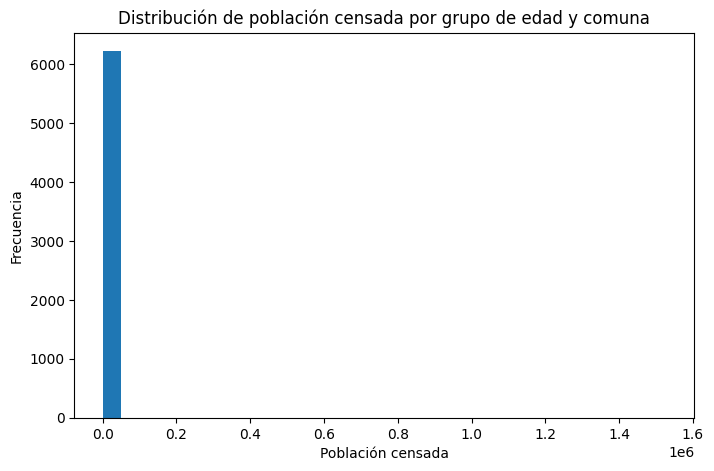

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(
    poblacion_detalle["Población censada"].dropna(),
    bins=30
)

plt.title("Distribución de población censada por grupo de edad y comuna")
plt.xlabel("Población censada")
plt.ylabel("Frecuencia")

plt.show()

In [29]:
poblacion_detalle.nlargest(
    10,
    "Población censada"
)[
    ["Región", "Comuna", "Grupos de edad", "Población censada"]
]

,Región,Comuna,Grupos de edad,Población censada
7,País,País,30 a 34,1527489.0
8,País,País,35 a 39,1408198.0
6,País,País,25 a 29,1383669.0
5,País,País,20 a 24,1273193.0
9,País,País,40 a 44,1270493.0
3,País,País,10 a 14,1256440.0
4,País,País,15 a 19,1219347.0
11,País,País,50 a 54,1173352.0
10,País,País,45 a 49,1151776.0
2,País,País,5 a 9,1147515.0


In [30]:
poblacion_detalle = poblacion[
    (~poblacion["Grupos de edad"].isin(["Total Comuna", "Total País"])) &
    (poblacion["Comuna"] != "País")
].copy()

poblacion_detalle = poblacion_detalle.dropna(subset=["Grupos de edad"])

In [31]:
poblacion_detalle["Comuna"].value_counts().head()

Comuna
Arica            18
Camarones        18
Putre            18
General Lagos    18
Iquique          18
Name: count, dtype: int64

In [32]:
poblacion_detalle.nlargest(
    10,
    "Población censada"
)[["Región", "Comuna", "Grupos de edad", "Población censada"]]

,Región,Comuna,Grupos de edad,Población censada
1584,Metropolitana de Santiago,Santiago,30 a 34,61778.0
1583,Metropolitana de Santiago,Santiago,25 a 29,51350.0
1585,Metropolitana de Santiago,Santiago,35 a 39,51082.0
2192,Metropolitana de Santiago,Puente Alto,30 a 34,46039.0
2191,Metropolitana de Santiago,Puente Alto,25 a 29,43407.0
2190,Metropolitana de Santiago,Puente Alto,20 a 24,42531.0
2193,Metropolitana de Santiago,Puente Alto,35 a 39,41913.0
2188,Metropolitana de Santiago,Puente Alto,10 a 14,40961.0
2189,Metropolitana de Santiago,Puente Alto,15 a 19,40382.0
1926,Metropolitana de Santiago,Maipú,30 a 34,39413.0


In [33]:
resumen_detalle = pd.DataFrame({
    "media": poblacion_detalle[variables_num].mean(),
    "mediana": poblacion_detalle[variables_num].median(),
    "moda": poblacion_detalle[variables_num].mode().iloc[0],
    "desviacion_std": poblacion_detalle[variables_num].std()
})

resumen_detalle.round(2)

,media,mediana,moda,desviacion_std
Población censada,2967.31,1063.0,0.0,5042.70
Hombres,1439.79,516.0,0.0,2491.95
Mujeres,1527.52,543.5,1.0,2562.03
Razón hombre-mujer,97.49,96.6,100.0,40.14


**Resultado descriptivo con la base depurada.** Las variables de población presentan una diferencia importante entre media y mediana, junto con una alta dispersión, lo que indica una distribución asimétrica influenciada por comunas de mayor tamaño poblacional. En cambio, la razón hombre-mujer se concentra en valores cercanos a 100.


In [34]:
poblacion_detalle[variables_num].skew().round(2)

Población censada      3.67
Hombres                3.87
Mujeres                3.52
Razón hombre-mujer    18.69
dtype: float64

In [35]:
poblacion_detalle["Razón hombre-mujer"].describe()

count    6204.000000
mean       97.493101
std        40.135503
min         0.000000
25%        88.300000
50%        96.600000
75%       104.100000
max      1300.000000
Name: Razón hombre-mujer, dtype: float64

In [36]:
poblacion_detalle.nlargest(
    10,
    "Razón hombre-mujer"
)[["Región", "Comuna", "Grupos de edad", "Razón hombre-mujer"]]

,Región,Comuna,Grupos de edad,Razón hombre-mujer
6486,Magallanes y de la Antártica Chilena,Antártica,30 a 34,1300.0
6585,Magallanes y de la Antártica Chilena,Torres del Paine,50 a 54,1300.0
6432,Magallanes y de la Antártica Chilena,Río Verde,45 a 49,1200.0
6489,Magallanes y de la Antártica Chilena,Antártica,45 a 49,1200.0
6485,Magallanes y de la Antártica Chilena,Antártica,25 a 29,900.0
6436,Magallanes y de la Antártica Chilena,Río Verde,65 a 69,700.0
6419,Magallanes y de la Antártica Chilena,Laguna Blanca,75 a 79,600.0
6413,Magallanes y de la Antártica Chilena,Laguna Blanca,45 a 49,500.0
6490,Magallanes y de la Antártica Chilena,Antártica,50 a 54,500.0
6550,Magallanes y de la Antártica Chilena,Timaukel,65 a 69,500.0


La razón hombre-mujer presenta una fuerte asimetría positiva debido a valores extremos concentrados principalmente en comunas de baja población. Estos valores no se consideran necesariamente erróneos, ya que pueden explicarse por tamaños poblacionales reducidos en determinados grupos de edad.

## 3. Visualización de la distribución

Se utilizan un histograma y un boxplot para complementar la revisión de forma y dispersión de la población censada.


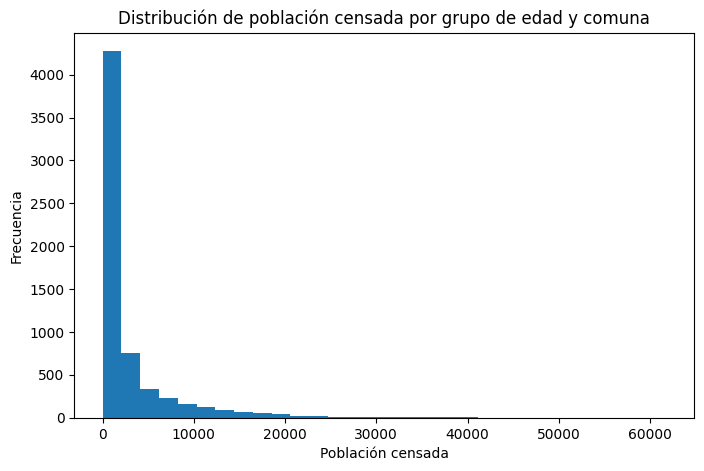

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    poblacion_detalle["Población censada"].dropna(),
    bins=30
)

plt.title("Distribución de población censada por grupo de edad y comuna")
plt.xlabel("Población censada")
plt.ylabel("Frecuencia")

plt.show()

El histograma muestra una distribución fuertemente asimétrica hacia la derecha, con la mayoría de las observaciones concentradas en valores bajos y una menor cantidad de grupos-comuna con poblaciones considerablemente mayores.


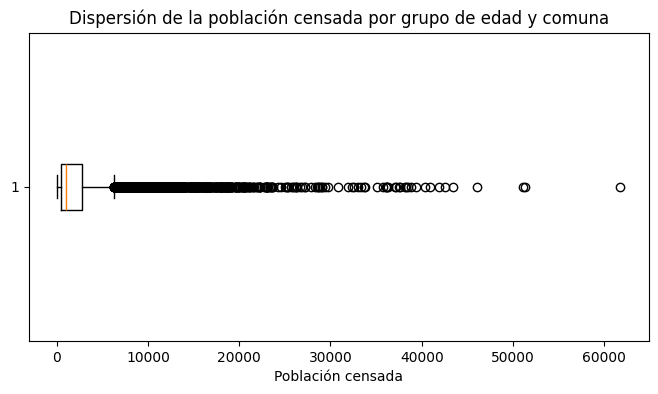

In [38]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    poblacion_detalle["Población censada"].dropna(),
    vert=False
)

plt.title("Dispersión de la población censada por grupo de edad y comuna")
plt.xlabel("Población censada")

plt.show()

**Cierre de la revisión univariada.** El boxplot confirma una alta dispersión y una marcada asimetría positiva. Los valores altos corresponden principalmente a comunas de mayor tamaño poblacional.

## 4. Análisis bivariado

A continuación se revisan las relaciones entre las variables cuantitativas mediante correlaciones de Pearson y Spearman.


In [39]:
corr_pearson = poblacion_detalle[variables_num].corr(method="pearson")

corr_pearson.round(2)

,Población censada,Hombres,Mujeres,Razón hombre-mujer
Población censada,1.00,1.00,1.00,-0.04
Hombres,1.00,1.00,0.99,-0.02
Mujeres,1.00,0.99,1.00,-0.05
Razón hombre-mujer,-0.04,-0.02,-0.05,1.00


La matriz de Pearson muestra una relación lineal muy fuerte entre población censada, hombres y mujeres, lo que resulta esperable por su composición. En cambio, la razón hombre-mujer presenta correlaciones cercanas a cero con las variables de tamaño poblacional.


In [40]:
corr_spearman = poblacion_detalle[variables_num].corr(method="spearman")

corr_spearman.round(2)

,Población censada,Hombres,Mujeres,Razón hombre-mujer
Población censada,1.00,1.00,1.00,-0.09
Hombres,1.00,1.00,0.99,-0.04
Mujeres,1.00,0.99,1.00,-0.14
Razón hombre-mujer,-0.09,-0.04,-0.14,1.00


La correlación de Spearman confirma las relaciones observadas con Pearson: población censada, hombres y mujeres presentan asociaciones muy fuertes, mientras que la razón hombre-mujer mantiene relaciones débiles con el tamaño poblacional.

Para cerrar el análisis bivariado, se representa gráficamente la relación entre hombres y mujeres.


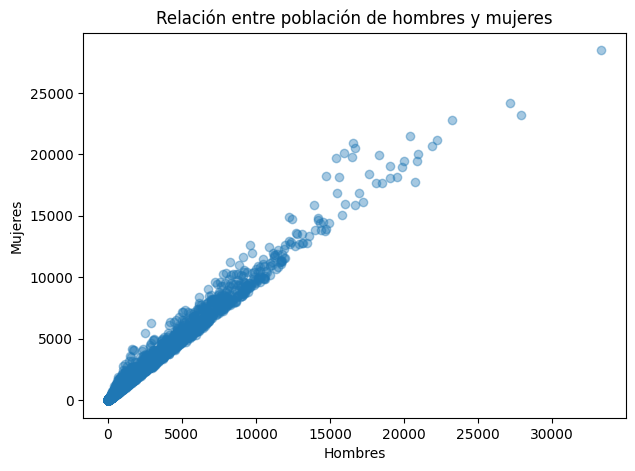

In [41]:
plt.figure(figsize=(7, 5))

plt.scatter(
    poblacion_detalle["Hombres"],
    poblacion_detalle["Mujeres"],
    alpha=0.4
)

plt.title("Relación entre población de hombres y mujeres")
plt.xlabel("Hombres")
plt.ylabel("Mujeres")

plt.show()

El gráfico de dispersión muestra una relación lineal muy fuerte entre la población de hombres y mujeres, consistente con los resultados obtenidos mediante Pearson y Spearman.

## 5. Cierre del análisis general

El análisis general permitió revisar la calidad, estructura y comportamiento de la base completa antes de utilizarla como fuente complementaria del proyecto. Se identificaron los distintos niveles de agregación, se depuró la base de detalle comunal y se revisaron las principales características de las variables poblacionales.

Dado que el caso de estudio corresponde a la Vendimia de San Fernando, a partir de este punto el análisis se focaliza en dicha comuna. El objetivo es utilizar la información censal como contexto para caracterizar la población local y, posteriormente, contrastarla con la estructura de los asistentes observada en la encuesta del evento.


# Parte II. Análisis enfocado en San Fernando

## 6. Selección de la comuna

Se filtran los registros correspondientes a San Fernando desde la base original. Se conserva inicialmente el registro de total comunal para poder revisar el tamaño poblacional de la comuna y, posteriormente, se separan los grupos de edad para el análisis de detalle.


In [ ]:
san_fernando = poblacion[
    poblacion["Comuna"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("san fernando")
].copy()

san_fernando.head()


In [ ]:
# Verificación del código de comuna y cantidad de registros disponibles
san_fernando[["Código comuna", "Comuna"]].drop_duplicates()


In [ ]:
# Revisar los grupos de edad disponibles para San Fernando
san_fernando["Grupos de edad"].value_counts(dropna=False)


La revisión anterior permite confirmar que la comuna se encuentra correctamente identificada dentro de la base y que cuenta con registros desagregados por grupos de edad. A continuación se separa el total comunal del detalle etario para evitar mezclar niveles de agregación.


In [ ]:
# Registro agregado de la comuna
san_fernando_total = san_fernando[
    san_fernando["Grupos de edad"].eq("Total Comuna")
]

san_fernando_total[
    ["Comuna", "Población censada", "Hombres", "Mujeres", "Razón hombre-mujer"]
]


In [ ]:
# Base de detalle por grupos de edad
san_fernando_detalle = san_fernando[
    ~san_fernando["Grupos de edad"].isin(["Total Comuna", "Total País"])
].copy()

san_fernando_detalle = san_fernando_detalle.dropna(subset=["Grupos de edad"])

san_fernando_detalle[
    ["Grupos de edad", "Población censada", "Hombres", "Mujeres", "Razón hombre-mujer"]
]


## 7. Estructura etaria de San Fernando

Se revisa la distribución de la población por grupo de edad. Esta información permitirá posteriormente comparar la estructura demográfica de la comuna con las edades observadas en la encuesta de asistentes a la Vendimia.


In [ ]:
# Participación de cada grupo de edad dentro de la población comunal
total_sf = san_fernando_detalle["Población censada"].sum()

san_fernando_detalle["Participación (%)"] = (
    san_fernando_detalle["Población censada"] / total_sf * 100
)

san_fernando_detalle[
    ["Grupos de edad", "Población censada", "Participación (%)"]
].round(2)


In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    san_fernando_detalle["Grupos de edad"],
    san_fernando_detalle["Población censada"]
)

plt.title("Población de San Fernando por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Población censada")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


El gráfico permite observar la distribución etaria de la población comunal sin mezclarla con otras comunas del país. En esta etapa se utiliza como descripción del contexto local; la comparación con la encuesta se realizará cuando ambas fuentes estén preparadas bajo grupos de edad compatibles.


## 8. Distribución por sexo y grupo de edad

Como complemento, se revisa la composición de hombres y mujeres dentro de cada grupo etario de San Fernando.


In [ ]:
plt.figure(figsize=(10, 5))

x = np.arange(len(san_fernando_detalle))
ancho = 0.4

plt.bar(
    x - ancho/2,
    san_fernando_detalle["Hombres"],
    width=ancho,
    label="Hombres"
)

plt.bar(
    x + ancho/2,
    san_fernando_detalle["Mujeres"],
    width=ancho,
    label="Mujeres"
)

plt.title("Población de San Fernando por sexo y grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Población censada")
plt.xticks(
    x,
    san_fernando_detalle["Grupos de edad"],
    rotation=45
)
plt.legend()
plt.tight_layout()

plt.show()


## 9. Cierre del enfoque comunal y hallazgos

1. La población de San Fernando presenta una composición relativamente equilibrada por sexo, aunque con una ligera mayoría femenina. La razón hombre-mujer comunal es cercana a 92, lo que equivale aproximadamente a 92 hombres por cada 100 mujeres.

2. La estructura por grupos de edad permite usar el Censo como referencia para contrastar la encuesta de la Vendimia. La base deja identificar qué tramos etarios tienen mayor peso dentro de la comuna y, posteriormente, comparar si los asistentes al evento siguen o no una distribución similar.

3. A nivel nacional, el tamaño de los grupos etarios varía fuertemente entre comunas. La distribución presenta asimetría positiva porque unas pocas comunas grandes concentran grupos de edad mucho más numerosos que la mayoría. Por eso, para el objetivo del proyecto, resulta más pertinente focalizar el análisis en San Fernando que interpretar los promedios nacionales.